
===== Visualizing features for A =====



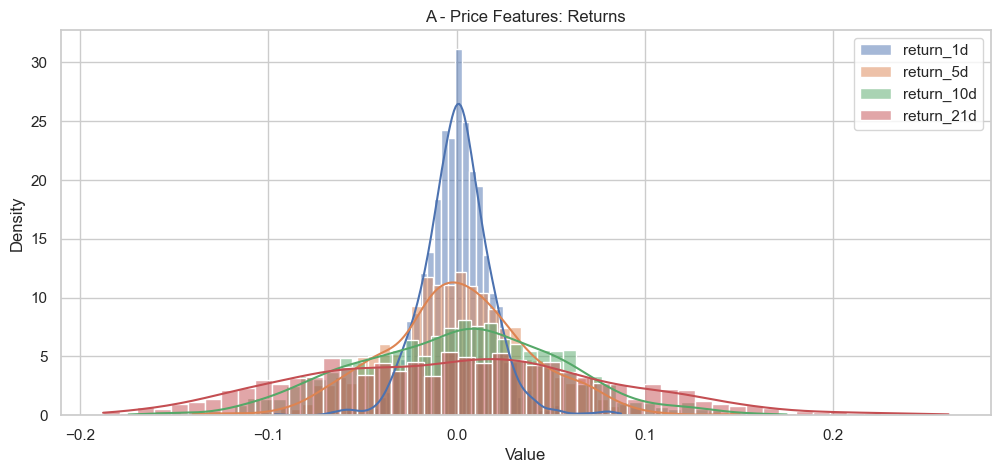

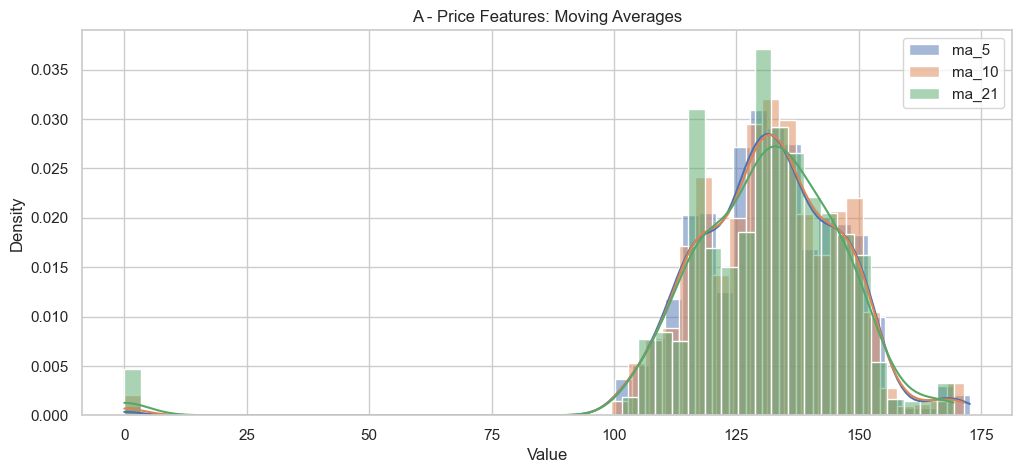

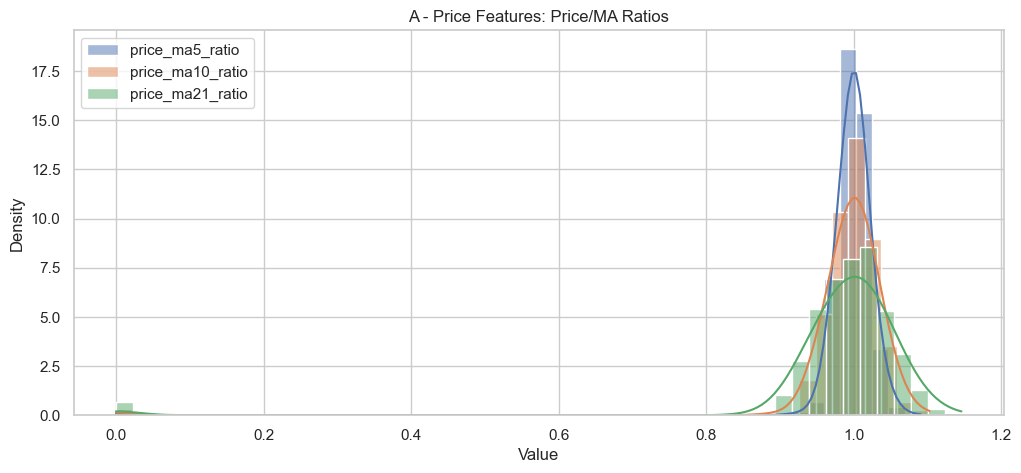

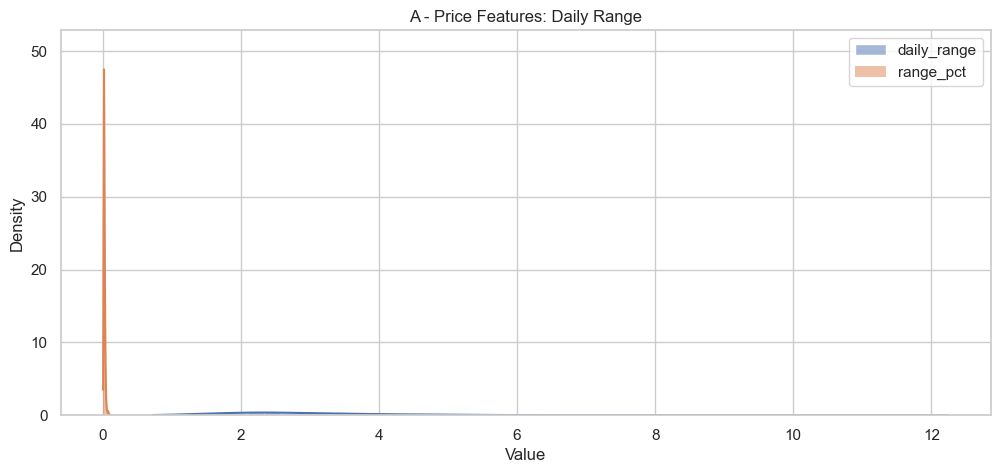

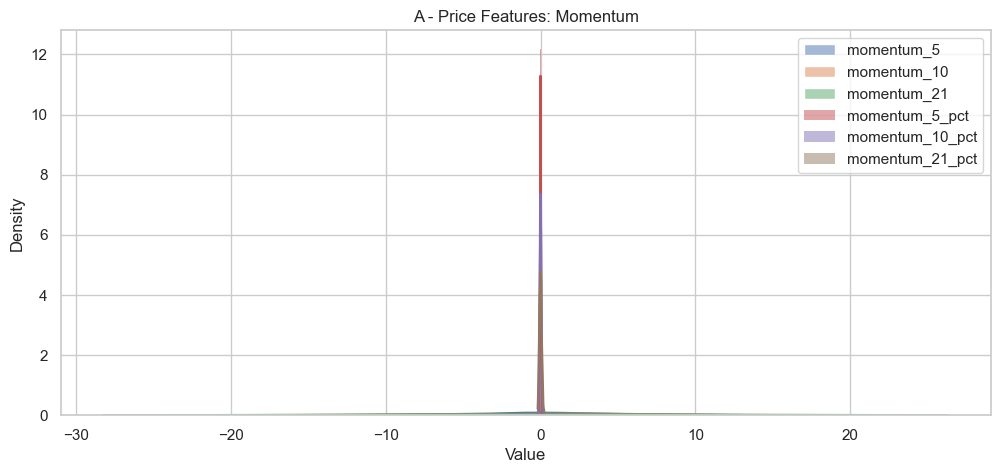

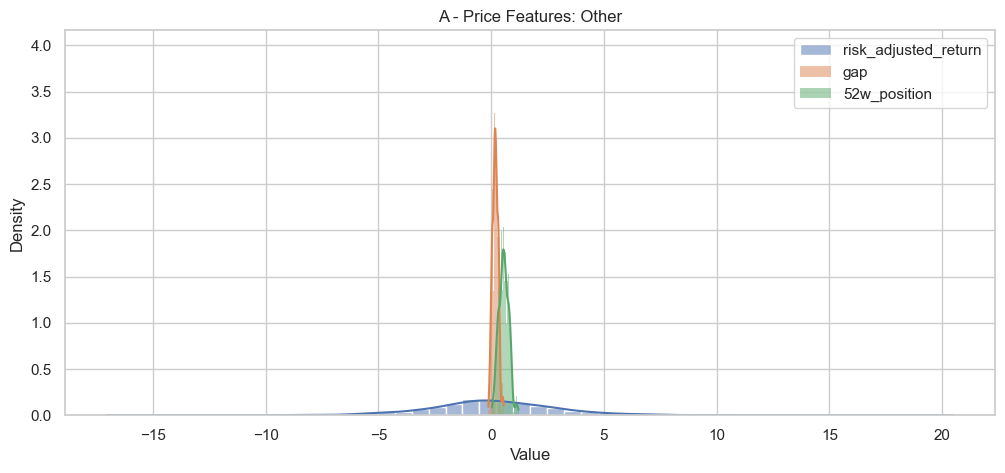

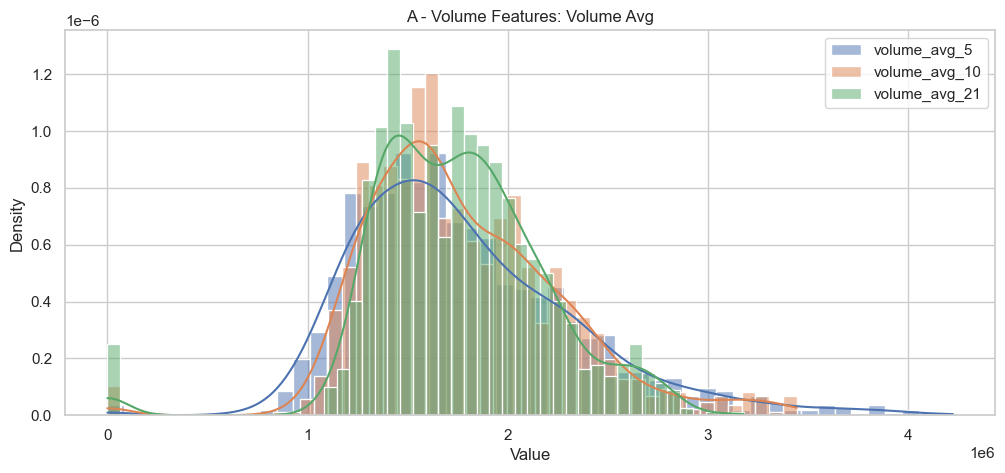

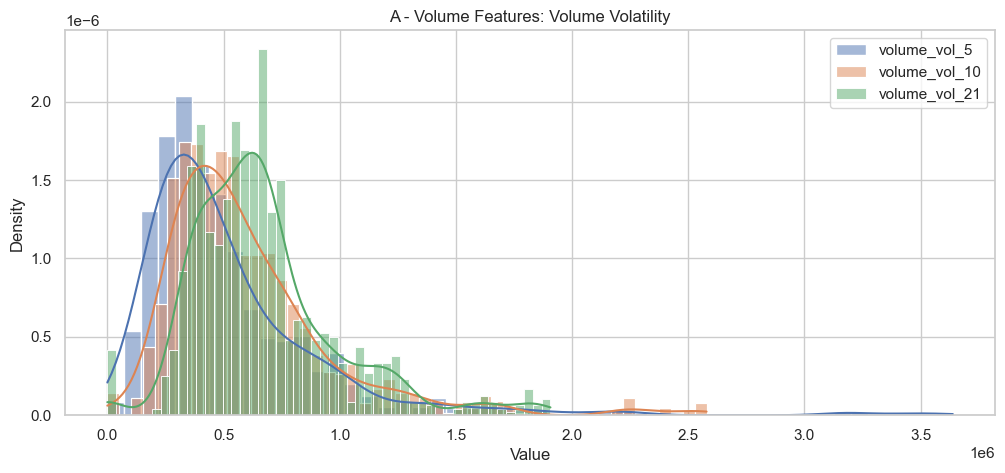

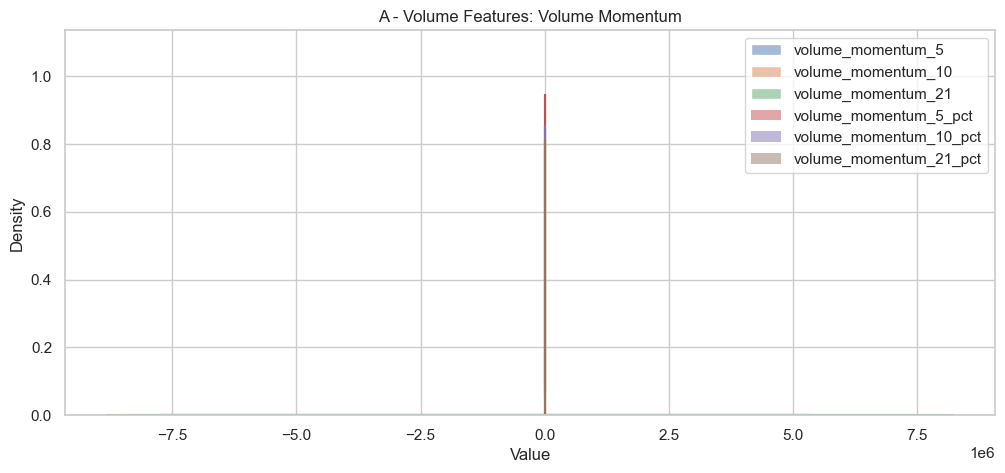

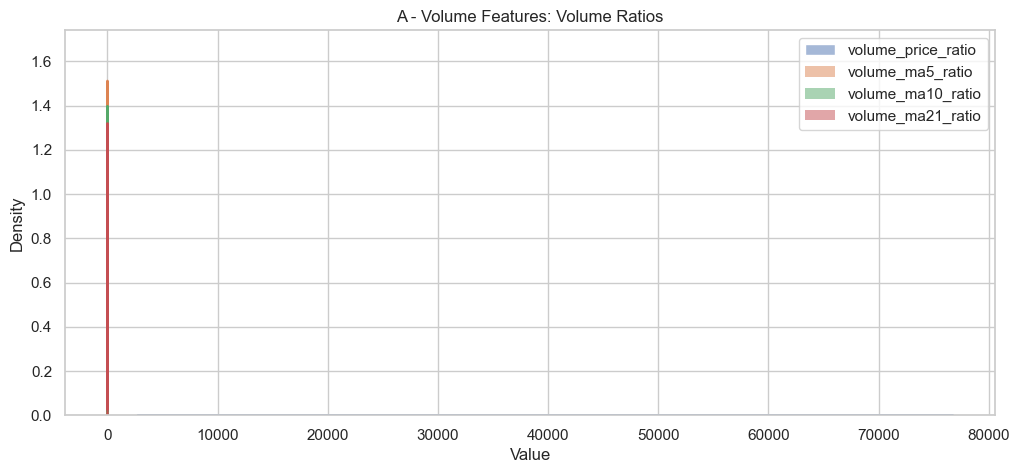

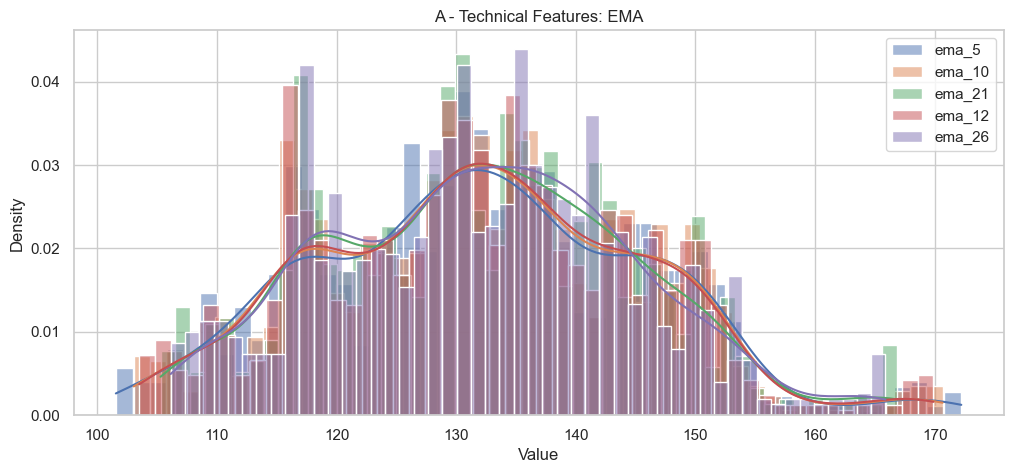

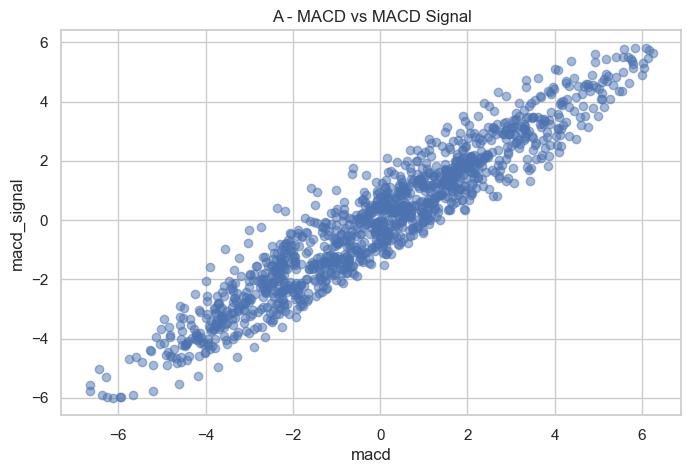

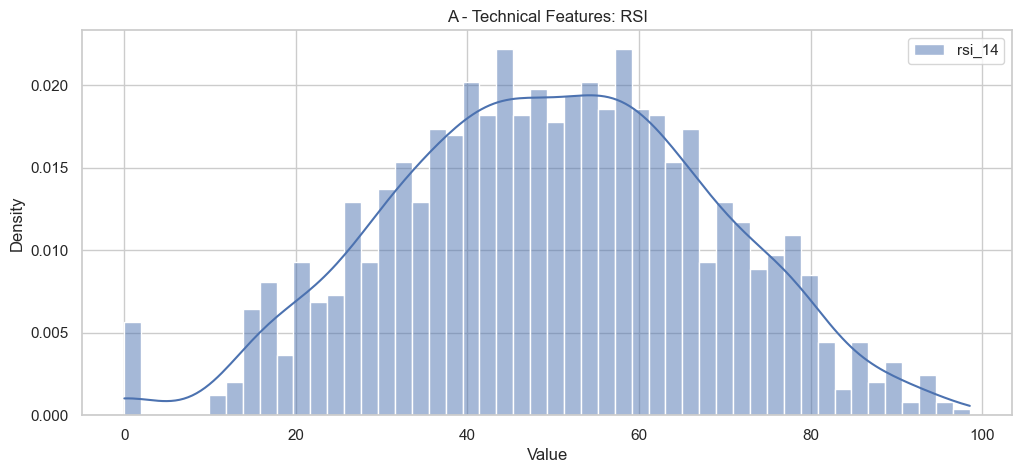

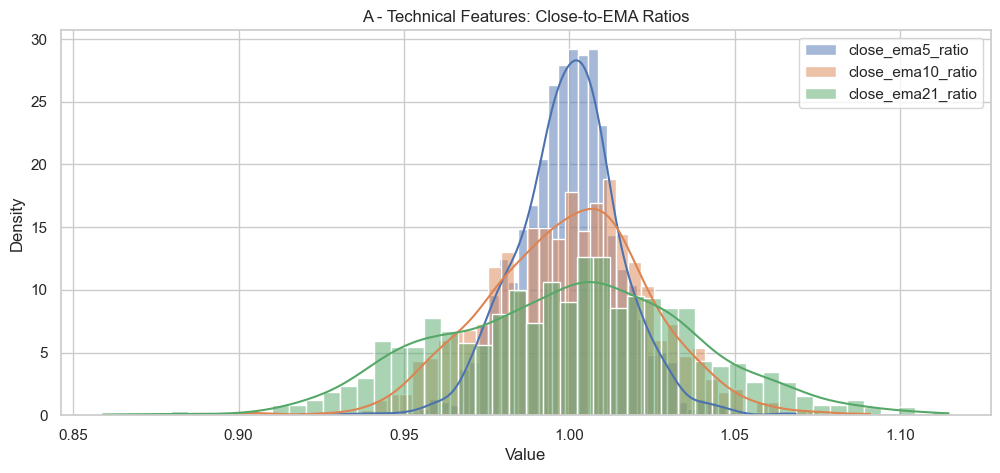


===== Visualizing features for ABBV =====



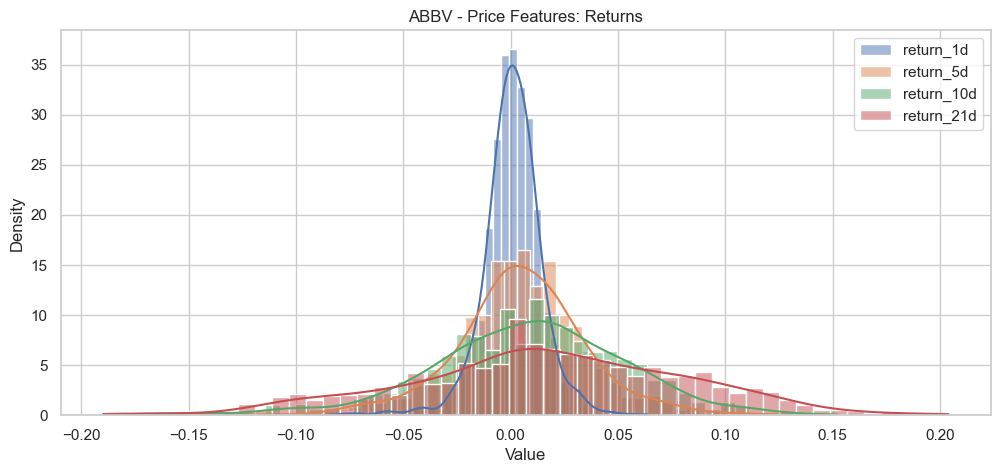

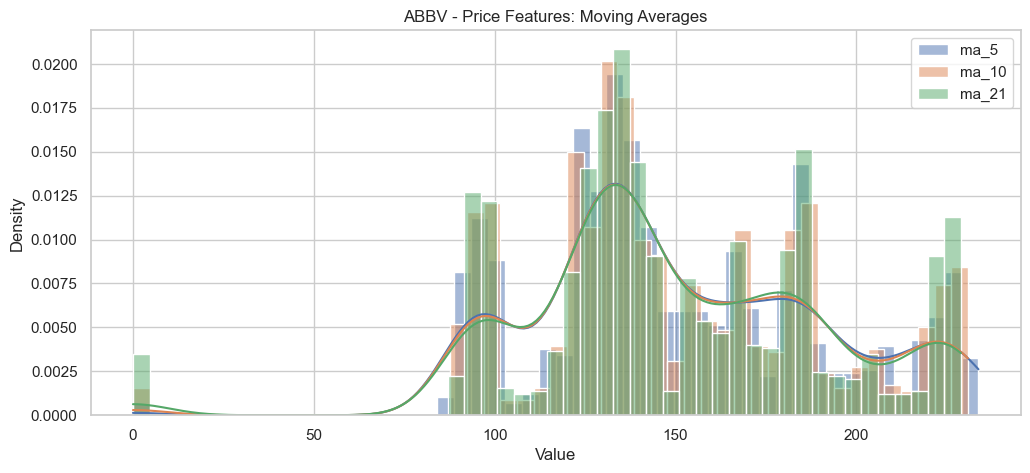

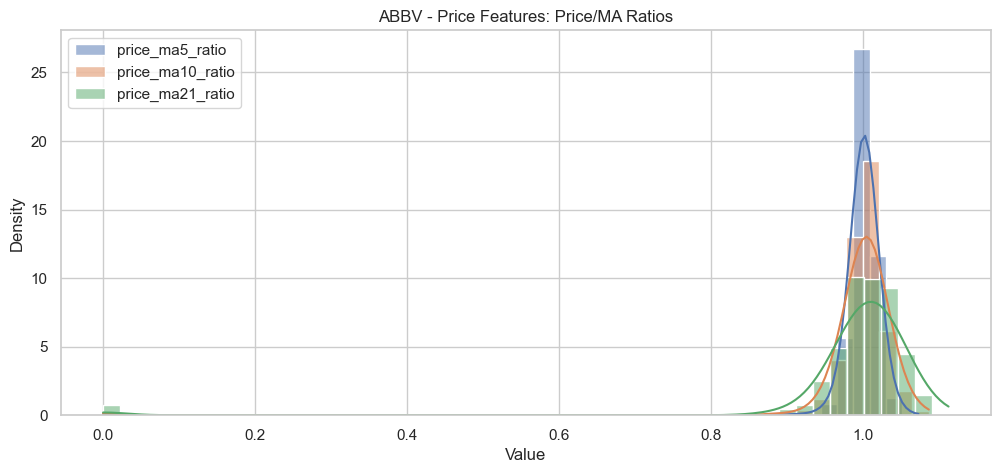

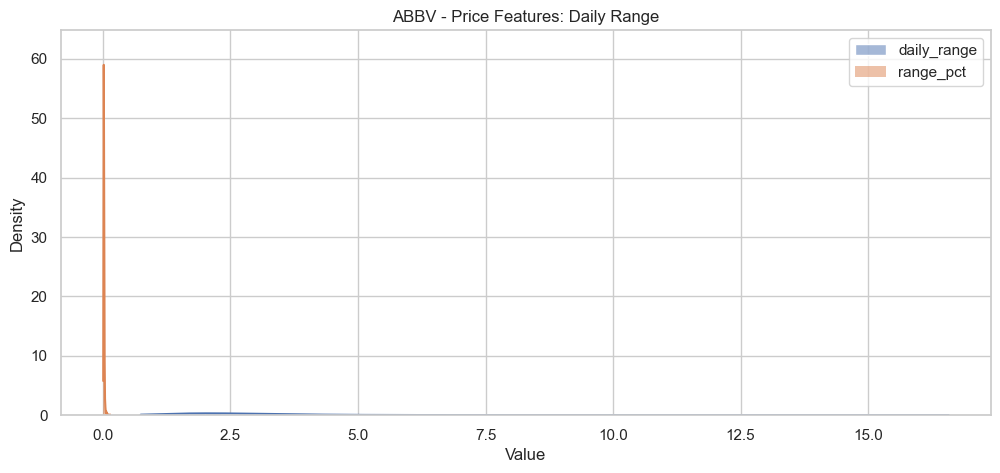

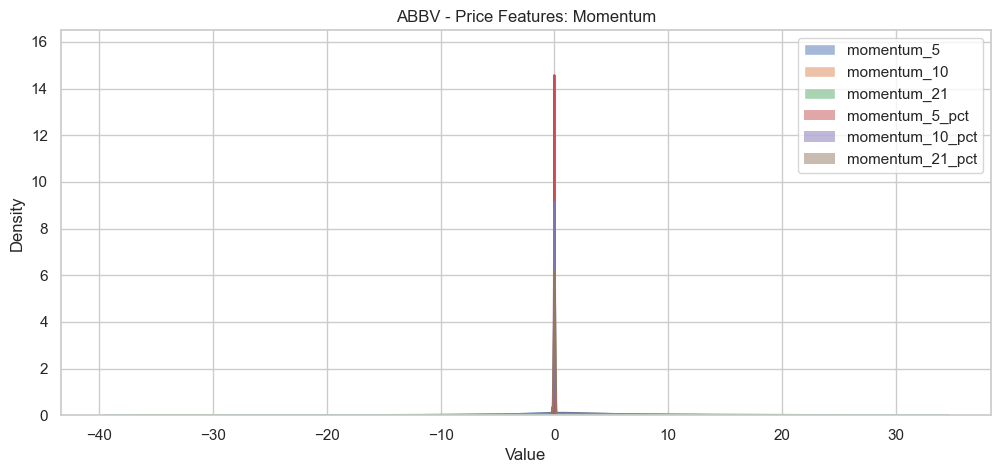

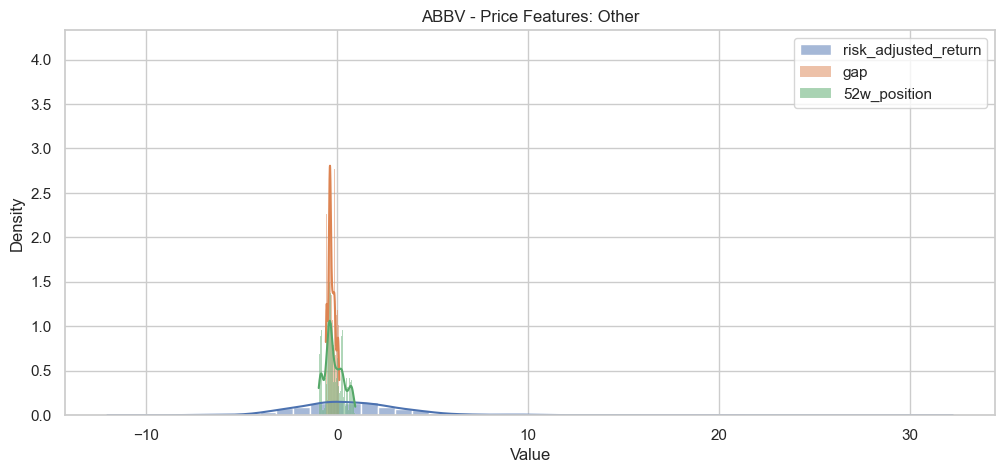

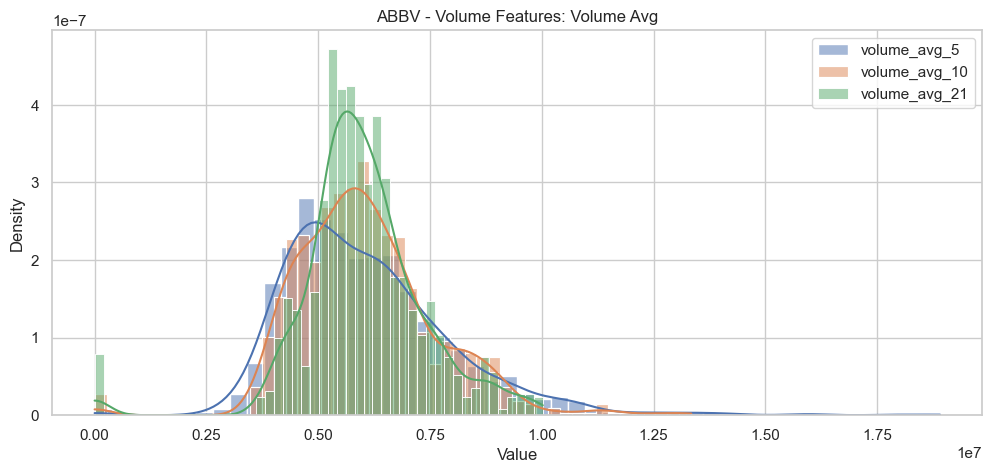

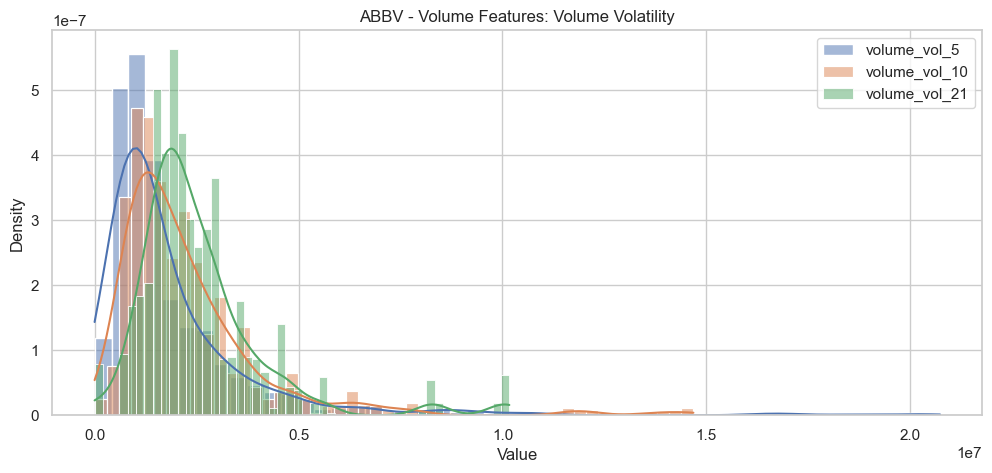

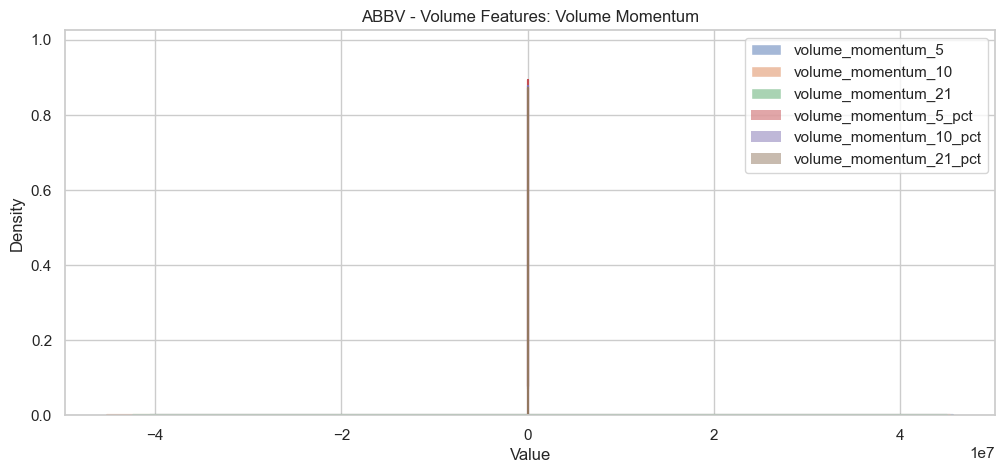

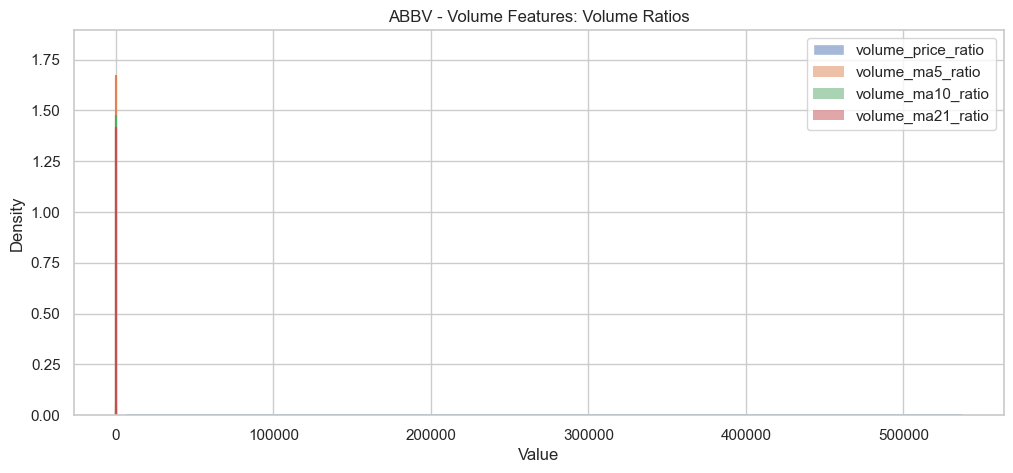

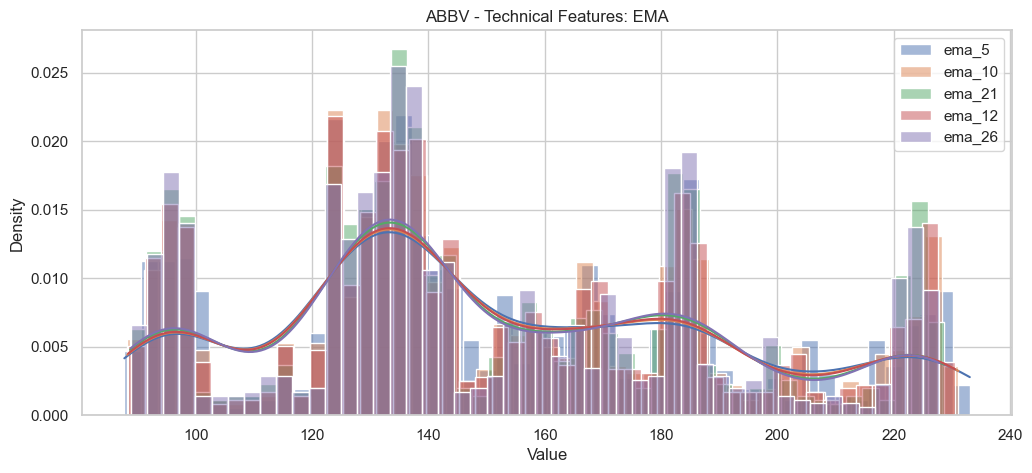

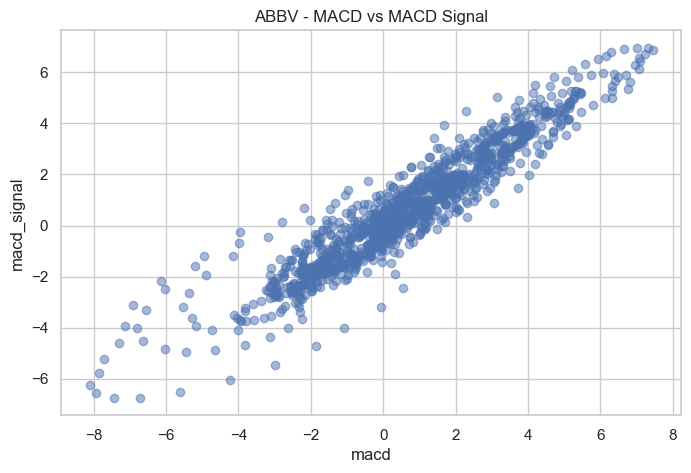

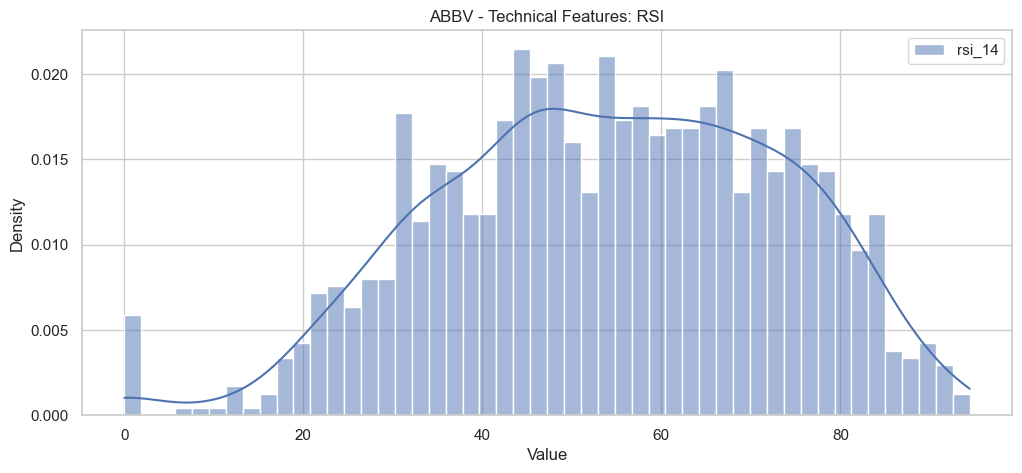

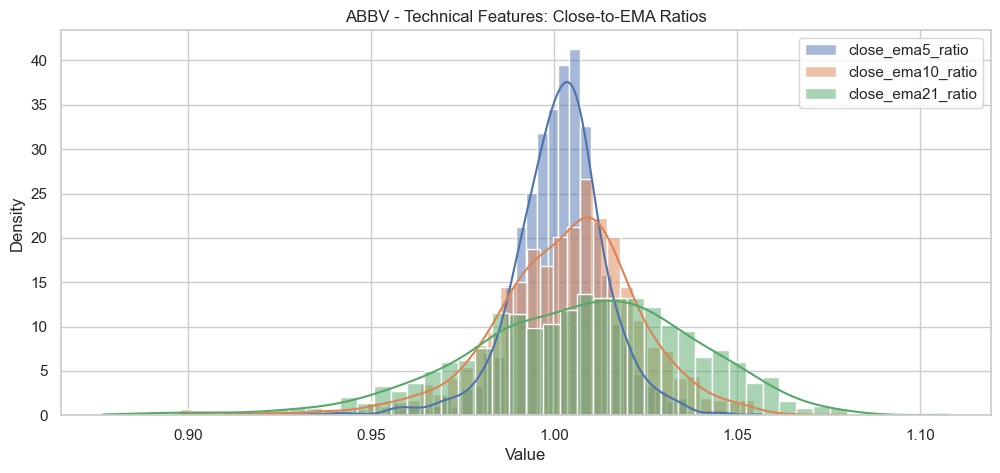


===== Visualizing features for ABT =====



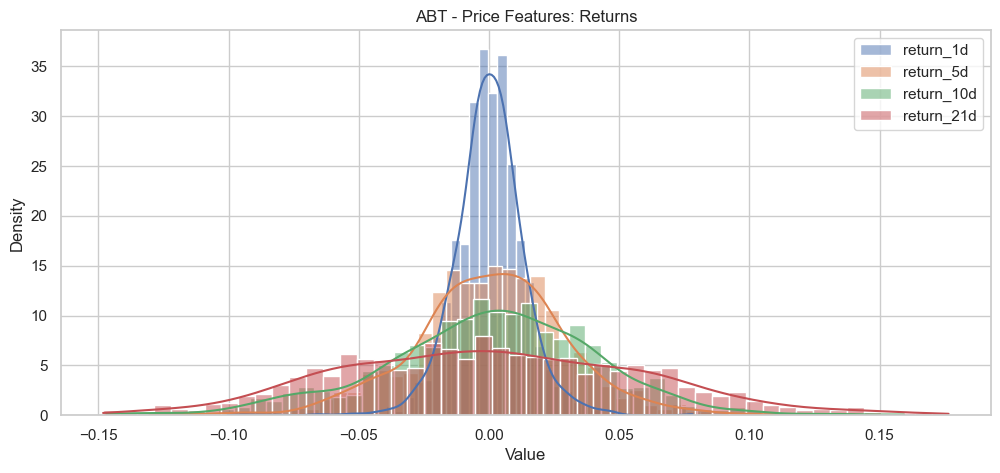

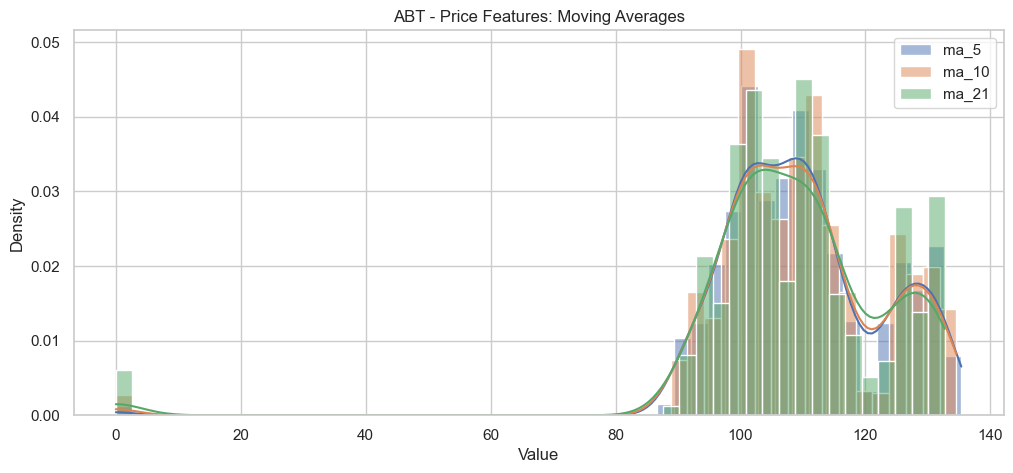

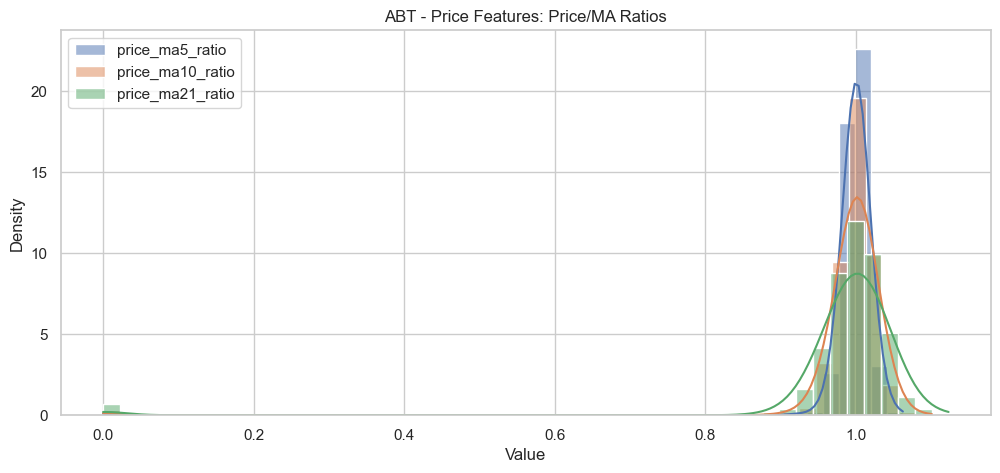

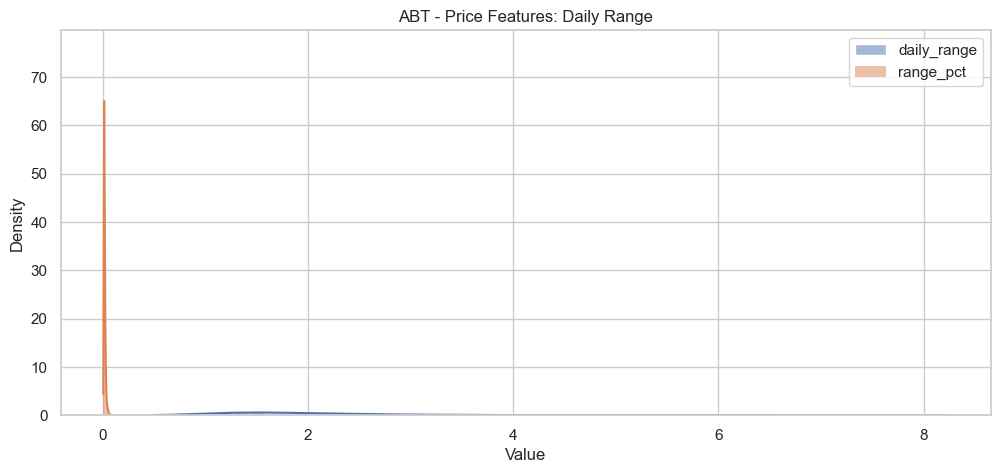

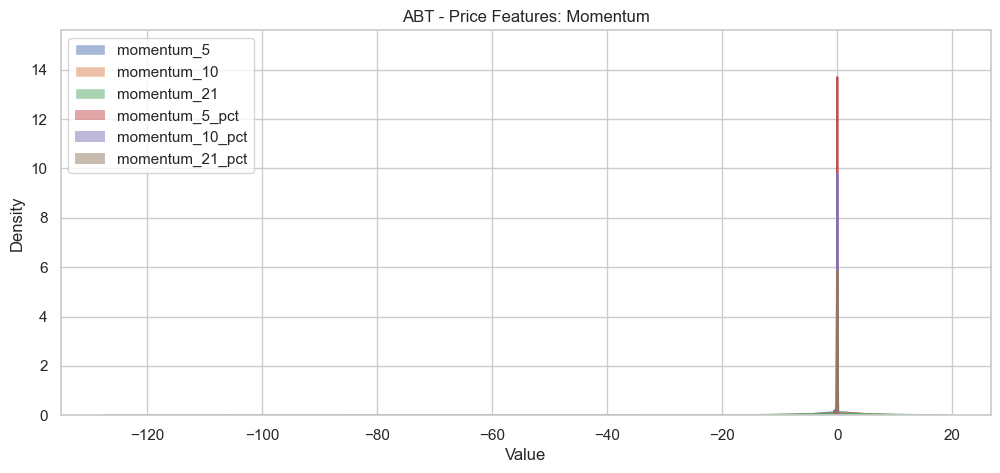

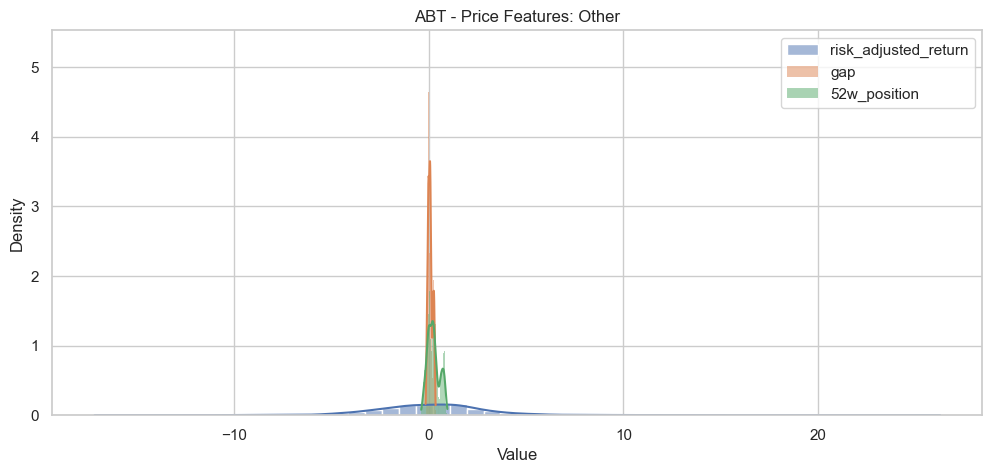

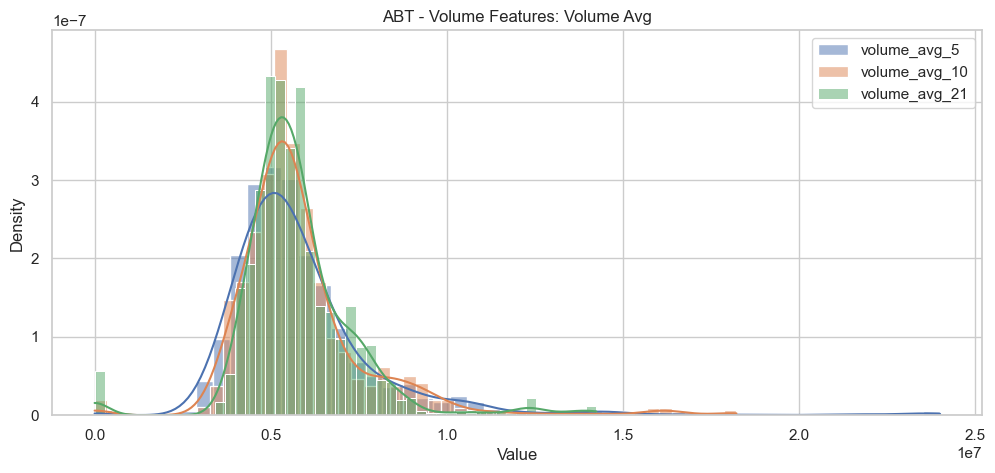

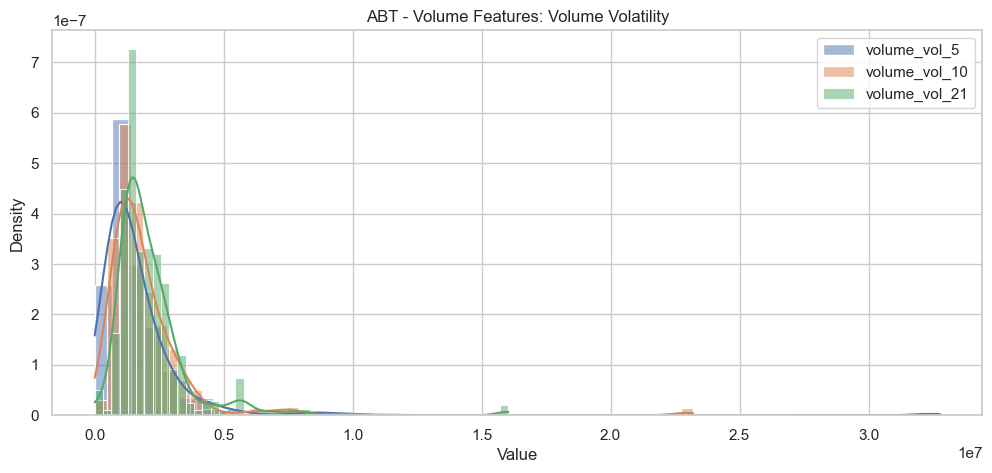

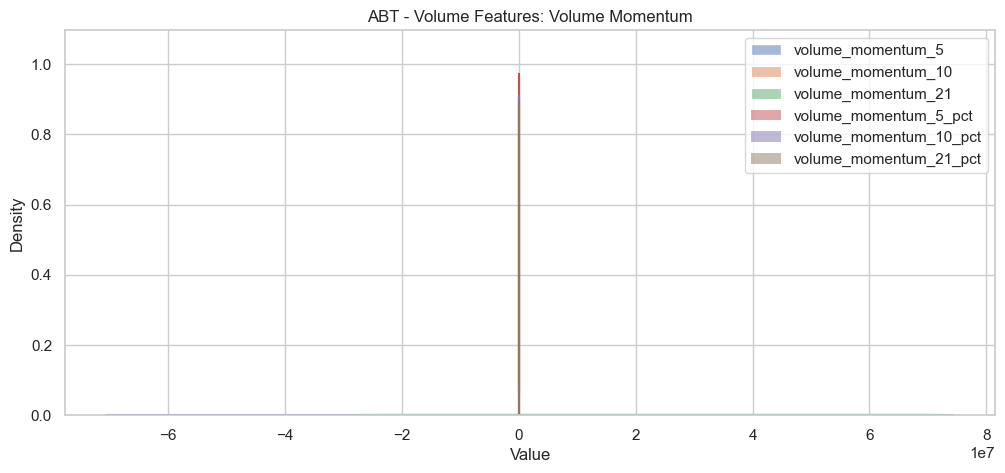

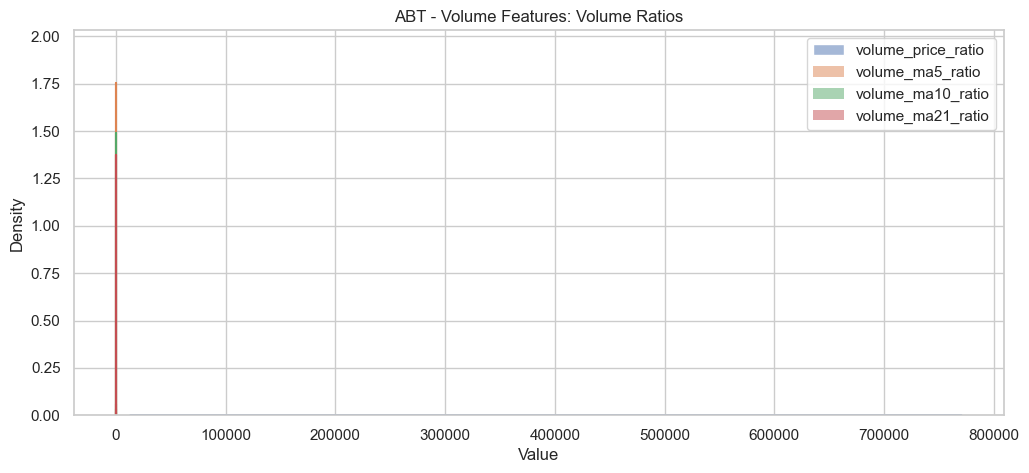

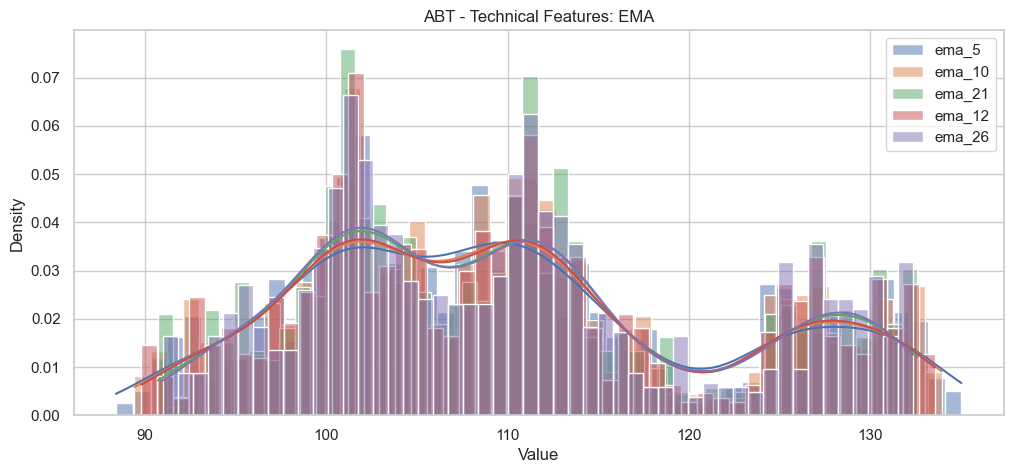

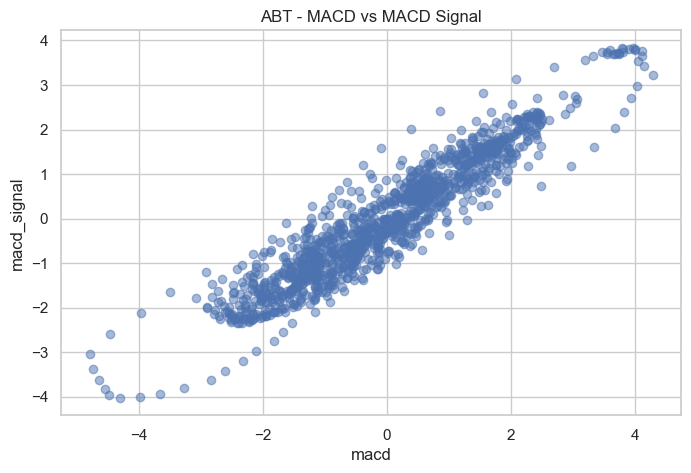

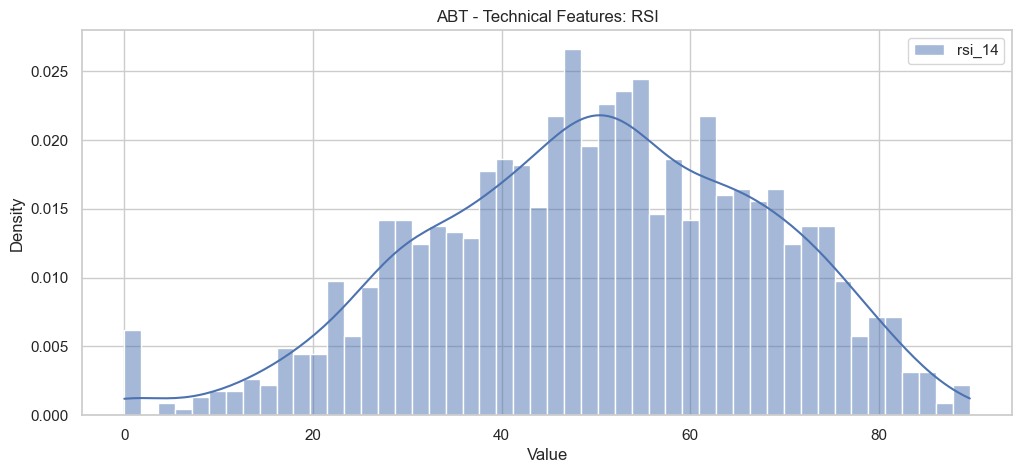

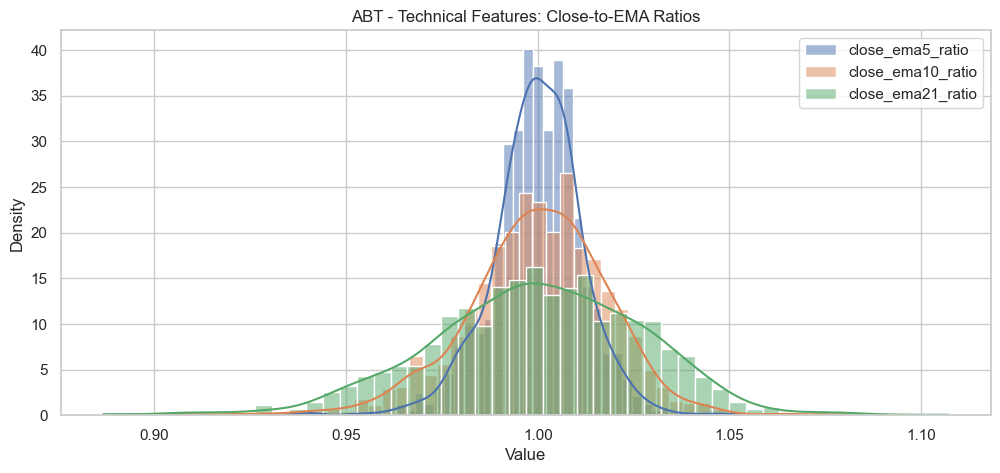

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

sns.set(style="whitegrid")
%matplotlib inline

# Load dataset
features = pd.read_csv("../data/processed/features_dataset.csv", low_memory=False)

# Pick first 3 tickers (adjust as needed)
tickers = features['Ticker'].unique()[:3]

# -------------------------------
# Define feature groups
# -------------------------------

# 1️⃣ Price-based features
price_features = {
    "Returns": ['return_1d','return_5d','return_10d','return_21d'],
    "Moving Averages": ['ma_5','ma_10','ma_21'],
    "Price/MA Ratios": ['price_ma5_ratio','price_ma10_ratio','price_ma21_ratio'],
    "Daily Range": ['daily_range','range_pct'],
    "Momentum": ['momentum_5','momentum_10','momentum_21','momentum_5_pct','momentum_10_pct','momentum_21_pct'],
    "Other": ['risk_adjusted_return','gap','52w_position']
}

# 2️⃣ Volume-based features
volume_features = {
    "Volume Avg": ['volume_avg_5','volume_avg_10','volume_avg_21'],
    "Volume Volatility": ['volume_vol_5','volume_vol_10','volume_vol_21'],
    "Volume Momentum": ['volume_momentum_5','volume_momentum_10','volume_momentum_21',
                        'volume_momentum_5_pct','volume_momentum_10_pct','volume_momentum_21_pct'],
    "Volume Ratios": ['volume_price_ratio','volume_ma5_ratio','volume_ma10_ratio','volume_ma21_ratio']
}

# 3️⃣ Technical/Other features
technical_features = {
    "EMA": ['ema_5','ema_10','ema_21','ema_12','ema_26'],
    "MACD": ['macd','macd_signal'],
    "RSI": ['rsi_14'],
    "Close-to-EMA Ratios": ['close_ema5_ratio','close_ema10_ratio','close_ema21_ratio']
}

# -------------------------------
# Function to plot histograms with KDE
# -------------------------------
def plot_feature_group(df, group_name, cols, ticker):
    plt.figure(figsize=(12,5))
    for col in cols:
        if col in df.columns:
            sns.histplot(df[col], bins=50, kde=True, label=col, stat="density", alpha=0.5)
    plt.title(f"{ticker} - {group_name}")
    plt.xlabel("Value")
    plt.ylabel("Density")
    plt.legend()
    plt.show()

# -------------------------------
# Loop through tickers and feature groups
# -------------------------------
for ticker in tickers:
    ticker_df = features[features['Ticker']==ticker]
    print(f"\n===== Visualizing features for {ticker} =====\n")
    
    # Price-based
    for group_name, cols in price_features.items():
        plot_feature_group(ticker_df, f"Price Features: {group_name}", cols, ticker)
    
    # Volume-based
    for group_name, cols in volume_features.items():
        plot_feature_group(ticker_df, f"Volume Features: {group_name}", cols, ticker)
    
    # Technical/Other
    for group_name, cols in technical_features.items():
        # For MACD, use scatter plot
        if group_name=="MACD":
            if all(c in ticker_df.columns for c in cols):
                plt.figure(figsize=(8,5))
                plt.scatter(ticker_df[cols[0]], ticker_df[cols[1]], alpha=0.5)
                plt.xlabel(cols[0])
                plt.ylabel(cols[1])
                plt.title(f"{ticker} - MACD vs MACD Signal")
                plt.show()
        else:
            plot_feature_group(ticker_df, f"Technical Features: {group_name}", cols, ticker)